In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.model_selection import GridSearchCV


shape of x:  (569, 30)
shape of y:  (569,)


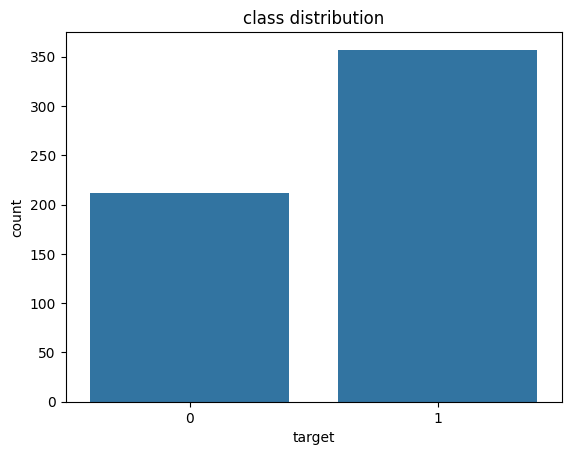

best performance:  {'metric': 'euclidean', 'n_neighbors': 8, 'weights': 'uniform'}
Best cross validation score 0.9670329670329672
TEst accuracy:  0.956140350877193

 confusion matrix: 
[[41  2]
 [ 3 68]]

 classification report: 
              precision    recall  f1-score   support

           0       0.93      0.95      0.94        43
           1       0.97      0.96      0.96        71

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114

Train Accuracy: 0.9758241758241758
Test Accuracy: 0.956140350877193


In [2]:
data = load_breast_cancer()


x = data.data
y = data.target

print("shape of x: ", x.shape)
print("shape of y: ", y.shape)
# df.head()
df = pd.DataFrame(x, columns=data.feature_names)
df['target'] = y

sns.countplot(x='target', data=df)
plt.title("class distribution")
plt.show()


X_train, X_test, y_train, y_test = train_test_split(
    x,y, test_size=0.2, random_state=42
)

scalar = StandardScaler()

X_train  =scalar.fit_transform(X_train)
X_test = scalar.transform(X_test)
knn = KNeighborsClassifier()

# k_values = range(1, 21)

# accuracy_score=[]



parameters = {
    'n_neighbors': list(range(1, 21)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid = GridSearchCV(estimator=knn, param_grid=parameters, cv=5, scoring='accuracy', n_jobs=-1)

grid.fit(X_train, y_train)

print("best performance: ", grid.best_params_)
print("Best cross validation score", grid.best_score_)

best_knn = grid.best_estimator_

y_pred = best_knn.predict(X_test)


print("TEst accuracy: ", accuracy_score(y_test, y_pred))
print("\n confusion matrix: ")
print(confusion_matrix(y_test, y_pred))

print("\n classification report: ")
print(classification_report(y_test, y_pred))



train_pred = best_knn.predict(X_train)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_pred))
      


